# Ablation figure + table generator

Reads a wandb CSV export (one row per run, columns include `probe/FP`, `probe/MP`,
`probe/DayM`, `probe/YearMD`, plus the sweep axes `numLayers`, `numHeads`, `EPOCHS`)
and emits, for each of the three studies (`heads`, `layers`, `epochs`):

1. A grouped bar chart → `figure/{study}.png`
2. A percentage table  → `figure/{study}_table.csv` + `figure/{study}_table.md`

| File | Sweep | Held fixed |
| --- | --- | --- |
| `figure/heads.png`,  `heads_table.{csv,md}`  | numHeads ∈ {2, 3, 6, 8}         | numLayers = 4, EPOCHS = 1 |
| `figure/layers.png`, `layers_table.{csv,md}` | numLayers ∈ {2, 3, 4, 6, 8, 10} | numHeads = 3, dmodel = 192, EPOCHS = 1 |
| `figure/epochs.png`, `epochs_table.{csv,md}` | EPOCHS ∈ {1, 2, 4, 6}           | numLayers = 4, numHeads = 3, dmodel = 192 |

In [2]:
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd

# Auto-detect the most recent wandb export anywhere under the notebook's dir;
# override CSV_PATH to pin a specific file.
CSV_PATH: str | None = None
if CSV_PATH is None:
    candidates = sorted(
        glob("wandb_export_*.csv")
        + glob("source-results/wandb_export_*.csv")
        + glob("../wandb_export_*.csv")
    )
    if not candidates:
        raise FileNotFoundError(
            "No wandb_export_*.csv found near this notebook. Drop the CSV in "
            "./source-results/ (or the notebook's directory) or set CSV_PATH above."
        )
    CSV_PATH = candidates[-1]
print(f"Reading {CSV_PATH}")

FIGURE_DIR = Path("figure")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


Reading source-results/wandb_export_2026-05-17T11_24_39.814-04_00.csv


In [3]:
df = pd.read_csv(CSV_PATH)

# Run names look like "heads-8-20260517-005847". Split into (study, value).
parts = df["Name"].str.split("-")
df["study"]       = parts.str[0]
df["sweep_value"] = parts.str[1].astype(int)

# Probe metrics, in probe code's natural order (easy → hard).
METRICS       = ["probe/MP", "probe/DayM", "probe/YearMD", "probe/FP"]
LABELS        = ["MP (month)", "DayM (day | M)", "YearMD (year | M,D)", "FP (full pred.)"]
SHORT_LABELS  = ["MP", "DayM", "YearMD", "FP"]
COLORS        = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

print(df.groupby("study")["Name"].count().rename("n_runs"))
df[["Name", "study", "sweep_value", *METRICS]].sort_values(["study", "sweep_value"])

study
epochs    4
heads     4
layers    6
Name: n_runs, dtype: int64


,Name,study,sweep_value,probe/MP,probe/DayM,probe/YearMD,probe/FP
13,epochs-1-20260517-005847,epochs,1,0.108261,0.769565,0.794348,0.050870
12,epochs-2-20260517-005847,epochs,2,0.813913,0.947826,0.941739,0.741739
11,epochs-4-20260517-005847,epochs,4,0.844783,0.982174,1.000000,0.830435
10,epochs-6-20260517-005847,epochs,6,0.907391,0.980000,0.978696,0.869565
3,heads-2-20260517-005847,heads,2,0.049130,0.020870,0.236957,0.000000
2,heads-3-20260517-005847,heads,3,0.073478,0.879565,0.822174,0.030435
1,heads-6-20260517-005847,heads,6,0.881304,0.998696,1.000000,0.880435
0,heads-8-20260517-005847,heads,8,0.850435,0.996087,0.999130,0.846957
9,layers-2-20260517-005847,layers,2,0.033478,0.123478,0.619130,0.003913
8,layers-3-20260517-005847,layers,3,0.070870,0.942174,0.857826,0.060870


In [4]:
AXIS_LABEL = {
    "heads":  "numHeads",
    "layers": "numLayers",
    "epochs": "EPOCHS",
}


def plot_study(study: str, x_label: str, fixed_config: str, out_name: str | None = None):
    """Grouped bar chart of MP / DayM / YearMD / FP across one sweep axis.

    Bar value labels and the y-axis ticks are both formatted as percentages
    (e.g. `85.0%`), even though the underlying probe values are fractions in
    [0, 1] — matplotlib's `PercentFormatter(xmax=1)` does the scaling.
    """
    sub = df[df["study"] == study].sort_values("sweep_value")
    if sub.empty:
        raise ValueError(
            f"No rows for study={study!r}. Found: {sorted(df['study'].unique())}"
        )

    x_vals = sub["sweep_value"].tolist()
    x      = np.arange(len(x_vals))
    bar_w  = 0.2
    offsets = (np.arange(len(METRICS)) - (len(METRICS) - 1) / 2) * bar_w

    fig_w = max(7, 1.2 * len(x_vals) + 4)
    fig, ax = plt.subplots(figsize=(fig_w, 4.8))

    for offset, metric, label, color in zip(offsets, METRICS, LABELS, COLORS):
        ys = sub[metric].values.astype(float)
        bars = ax.bar(
            x + offset, ys, bar_w,
            label=label, color=color, edgecolor="white", linewidth=0.5,
        )
        for bar, y in zip(bars, ys):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y + 0.012,
                f"{y * 100:.1f}%",
                ha="center", va="bottom", fontsize=7, color="#333",
            )

    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in x_vals])
    ax.set_xlabel(x_label)
    ax.set_ylabel("Probe accuracy")
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.set_title(f"Ablation — {study} sweep\n({fixed_config})", fontsize=11)
    ax.legend(loc="lower right", fontsize=8, framealpha=0.92)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    fig.tight_layout()

    out_path = FIGURE_DIR / (out_name or f"{study}.png")
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path}")


def build_table(study: str) -> pd.DataFrame:
    """Per-study table indexed by sweep value, columns = MP/DayM/YearMD/FP (%)."""
    sub = df[df["study"] == study].sort_values("sweep_value")
    if sub.empty:
        raise ValueError(f"No rows for study={study!r}.")
    tbl = sub.set_index("sweep_value")[METRICS]
    tbl.columns = SHORT_LABELS
    tbl.index.name = AXIS_LABEL[study]
    return (tbl.astype(float) * 100).round(1)


def df_to_markdown(d: pd.DataFrame) -> str:
    """Render a DataFrame as a GitHub-flavored markdown table with `xx.x%` cells.

    Avoids the optional `tabulate` dep that pandas' built-in `to_markdown` requires.
    """
    cols   = list(d.columns)
    header = "| " + (d.index.name or "") + " | " + " | ".join(cols) + " |"
    sep    = "|" + "|".join([" --- "] * (len(cols) + 1)) + "|"
    rows   = [
        "| " + str(i) + " | " + " | ".join(f"{d.at[i, c]:.1f}%" for c in cols) + " |"
        for i in d.index
    ]
    return "\n".join([header, sep, *rows])


def show_and_save_table(study: str) -> pd.DataFrame:
    """Print + save the percentage table for one study. Returns the styled DataFrame."""
    tbl = build_table(study)

    # Persist machine-readable CSV (raw percentages, one decimal).
    csv_path = FIGURE_DIR / f"{study}_table.csv"
    tbl.to_csv(csv_path)

    # Persist human-readable markdown.
    md_path = FIGURE_DIR / f"{study}_table.md"
    md_path.write_text(
        f"### Ablation — {study} sweep (probe accuracy %)\n\n" + df_to_markdown(tbl) + "\n"
    )
    print(f"Saved → {csv_path}")
    print(f"Saved → {md_path}")

    # Return a Styler so the rendered cell shows e.g. `85.0%`.
    return tbl.style.format("{:.1f}%").set_caption(f"{study} sweep — probe accuracy")


## Heads sweep

Holding `numLayers = 4`, `EPOCHS = 1`. `dmodel = 64 · numHeads` per the paper's ℓ-h convention.

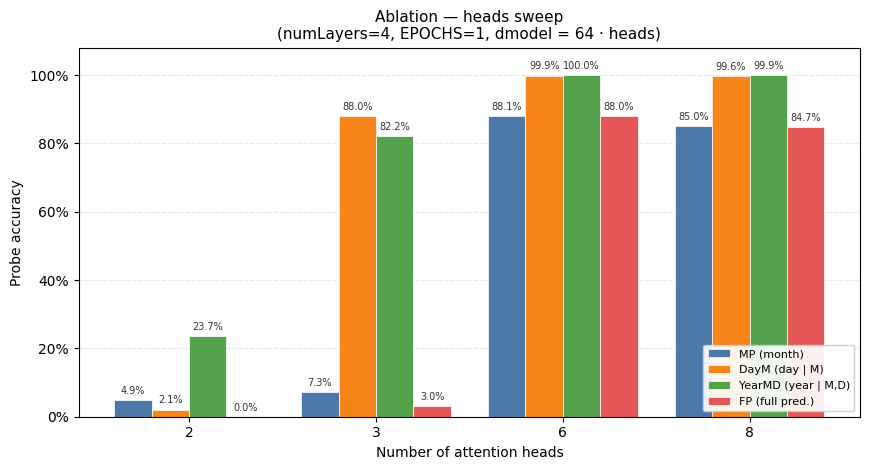

Saved → figure/heads.png


In [20]:
plot_study(
    study="heads",
    x_label="Number of attention heads",
    fixed_config="numLayers=4, EPOCHS=1, dmodel = 64 · heads",
)

In [21]:
show_and_save_table("heads")

Saved → figure/heads_table.csv
Saved → figure/heads_table.md


,MP,DayM,YearMD,FP
numHeads,,,,
2,4.9%,2.1%,23.7%,0.0%
3,7.3%,88.0%,82.2%,3.0%
6,88.1%,99.9%,100.0%,88.0%
8,85.0%,99.6%,99.9%,84.7%


## Layers sweep

Holding `numHeads = 3` (so `dmodel = 192`) and `EPOCHS = 1`.

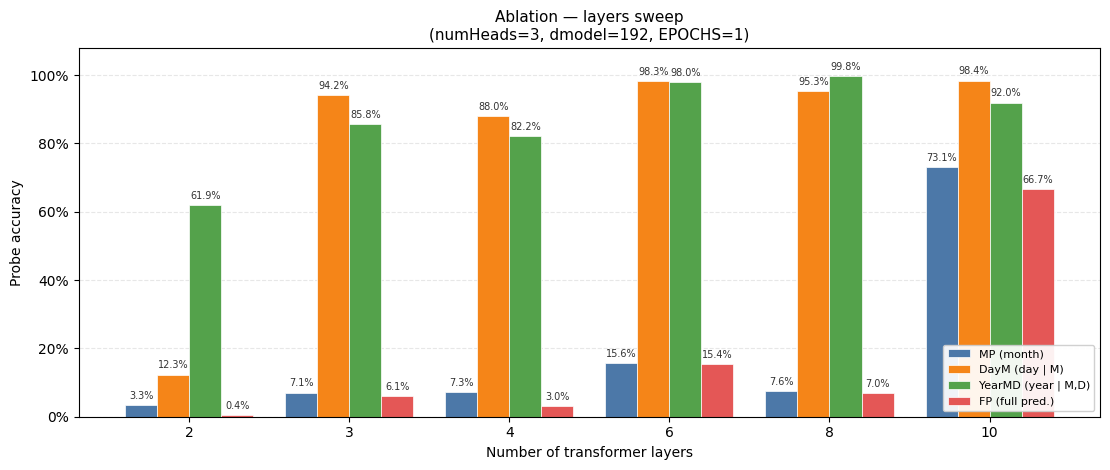

Saved → figure/layers.png


In [22]:
plot_study(
    study="layers",
    x_label="Number of transformer layers",
    fixed_config="numHeads=3, dmodel=192, EPOCHS=1",
)

In [23]:
show_and_save_table("layers")

Saved → figure/layers_table.csv
Saved → figure/layers_table.md


,MP,DayM,YearMD,FP
numLayers,,,,
2,3.3%,12.3%,61.9%,0.4%
3,7.1%,94.2%,85.8%,6.1%
4,7.3%,88.0%,82.2%,3.0%
6,15.6%,98.3%,98.0%,15.4%
8,7.6%,95.3%,99.8%,7.0%
10,73.1%,98.4%,92.0%,66.7%


## Epochs sweep

Holding `numLayers = 4`, `numHeads = 3`, `dmodel = 192`.

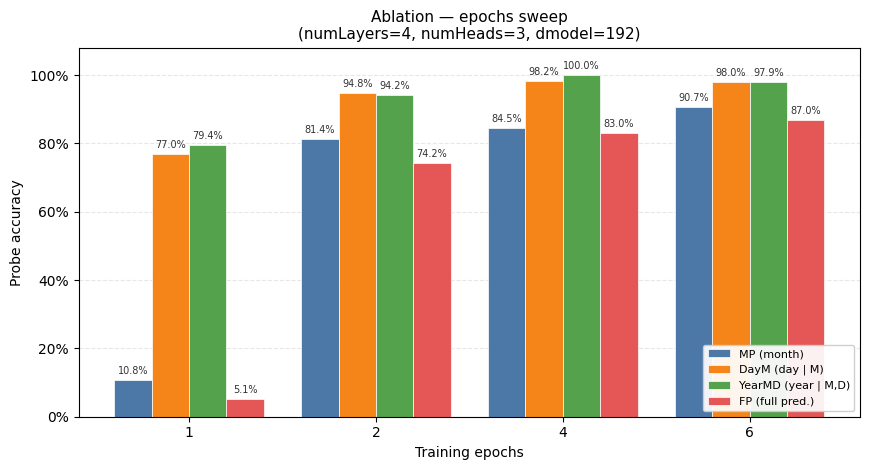

Saved → figure/epochs.png


In [24]:
plot_study(
    study="epochs",
    x_label="Training epochs",
    fixed_config="numLayers=4, numHeads=3, dmodel=192",
)

In [25]:
show_and_save_table("epochs")

Saved → figure/epochs_table.csv
Saved → figure/epochs_table.md


,MP,DayM,YearMD,FP
EPOCHS,,,,
1,10.8%,77.0%,79.4%,5.1%
2,81.4%,94.8%,94.2%,74.2%
4,84.5%,98.2%,100.0%,83.0%
6,90.7%,98.0%,97.9%,87.0%


## Epoch scaling — combined

Combines the original epoch sweep (`epochs ∈ {1, 2, 4, 6}` from the wandb export)
with the new Llama LM4 sweep (`epochs ∈ {6, 8, 10, 12, 16}` from
`source-results/epoch-scailing-llamalm4.csv`). Where both sources have `epochs=6`,
the Llama LM4 row is kept.

All runs hold `numLayers = 4`, `numHeads = 3`, `dmodel = 192`.

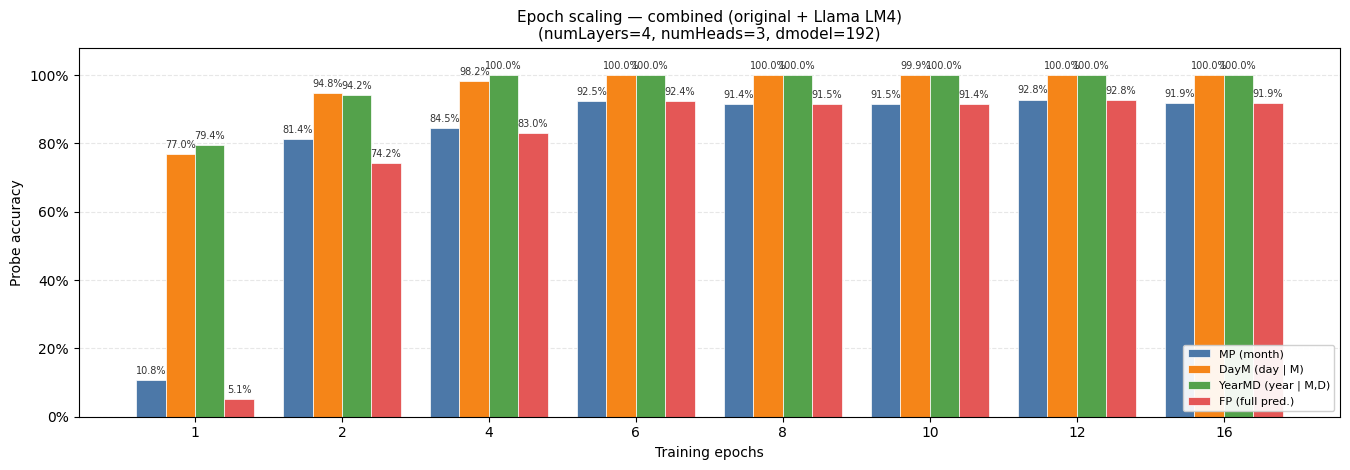

Saved → figure/epoch_scaling_combined.png
Saved → figure/epoch_scaling_combined_table.csv
Saved → figure/epoch_scaling_combined_table.md


,MP,DayM,YearMD,FP
EPOCHS,,,,
1,10.8%,77.0%,79.4%,5.1%
2,81.4%,94.8%,94.2%,74.2%
4,84.5%,98.2%,100.0%,83.0%
6,92.5%,100.0%,100.0%,92.4%
8,91.4%,100.0%,100.0%,91.5%
10,91.5%,99.9%,100.0%,91.4%
12,92.8%,100.0%,100.0%,92.8%
16,91.9%,100.0%,100.0%,91.9%


In [8]:
LLAMA_EPOCH_CSV = "source-results/epoch-scailing-llamalm4.csv"

llama_df = pd.read_csv(LLAMA_EPOCH_CSV)
llama_df["sweep_value"] = llama_df["Name"].str.split("-").str[1].astype(int)

prev_epochs = df.loc[df["study"] == "epochs", ["sweep_value", *METRICS]].copy()
new_epochs  = llama_df[["sweep_value", *METRICS]].copy()

# Prefer the new Llama LM4 row when the same epoch appears in both sources.
combined = (
    pd.concat([prev_epochs, new_epochs], ignore_index=True)
      .drop_duplicates(subset="sweep_value", keep="last")
      .sort_values("sweep_value")
      .reset_index(drop=True)
)

x_vals = combined["sweep_value"].tolist()
x      = np.arange(len(x_vals))
bar_w  = 0.2
offsets = (np.arange(len(METRICS)) - (len(METRICS) - 1) / 2) * bar_w

fig_w = max(7, 1.2 * len(x_vals) + 4)
fig, ax = plt.subplots(figsize=(fig_w, 4.8))

for offset, metric, label, color in zip(offsets, METRICS, LABELS, COLORS):
    ys = combined[metric].values.astype(float)
    bars = ax.bar(
        x + offset, ys, bar_w,
        label=label, color=color, edgecolor="white", linewidth=0.5,
    )
    for bar, y in zip(bars, ys):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y + 0.012,
            f"{y * 100:.1f}%",
            ha="center", va="bottom", fontsize=7, color="#333",
        )

ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in x_vals])
ax.set_xlabel("Training epochs")
ax.set_ylabel("Probe accuracy")
ax.set_ylim(0, 1.08)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_title(
    "Epoch scaling — combined (original + Llama LM4)\n"
    "(numLayers=4, numHeads=3, dmodel=192)",
    fontsize=11,
)
ax.legend(loc="lower right", fontsize=8, framealpha=0.92)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()

out_path = FIGURE_DIR / "epoch_scaling_combined.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

combined_tbl = combined.set_index("sweep_value")[METRICS]
combined_tbl.columns = SHORT_LABELS
combined_tbl.index.name = "EPOCHS"
combined_tbl = (combined_tbl.astype(float) * 100).round(1)

csv_path = FIGURE_DIR / "epoch_scaling_combined_table.csv"
md_path  = FIGURE_DIR / "epoch_scaling_combined_table.md"
combined_tbl.to_csv(csv_path)
md_path.write_text(
    "### Epoch scaling — combined (probe accuracy %)\n\n"
    + df_to_markdown(combined_tbl) + "\n"
)
print(f"Saved → {csv_path}")
print(f"Saved → {md_path}")

combined_tbl.style.format("{:.1f}%").set_caption("Combined epoch scaling — probe accuracy")

## Scaling study — GPT-2 ablation (heads / layers / epochs)

Reads `source-results/scailingStudy.csv` (the GPT-2 ablation export,
`bioS_name_date_small_gpt_abalation`) and renders all three sweeps with
the same MP / DayM / YearMD / FP bar-chart style. Outputs are prefixed
`scaling_` so they don't clobber the original figures.

study
epochs    4
heads     4
layers    6
Name: n_runs, dtype: int64


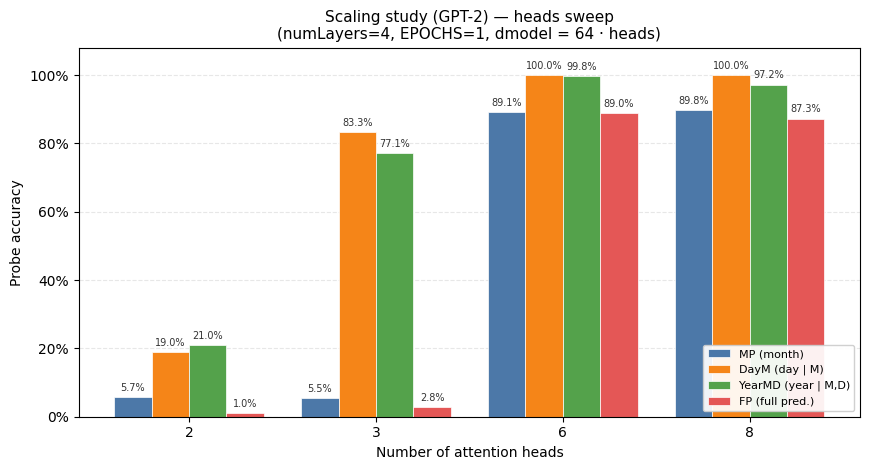

Saved → figure/scaling_heads.png
Saved → figure/scaling_heads_table.csv
Saved → figure/scaling_heads_table.md


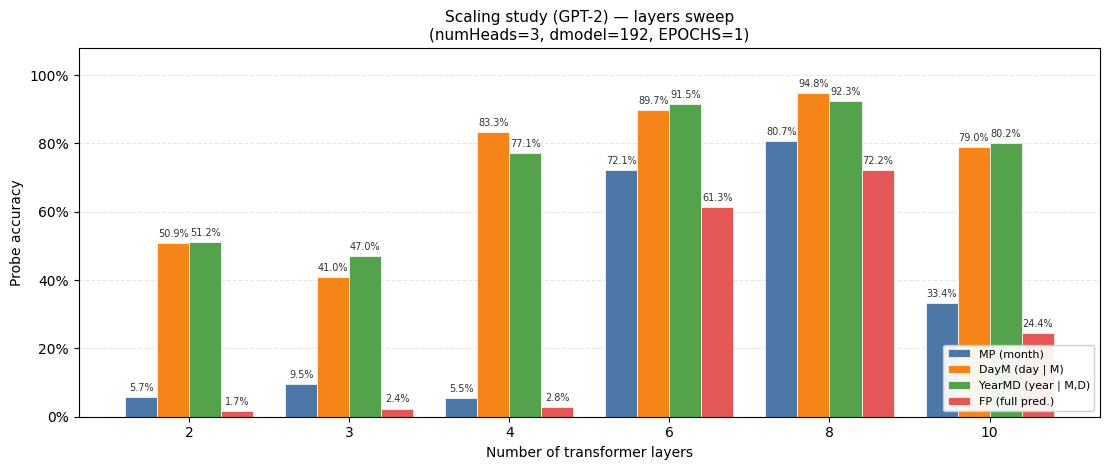

Saved → figure/scaling_layers.png
Saved → figure/scaling_layers_table.csv
Saved → figure/scaling_layers_table.md


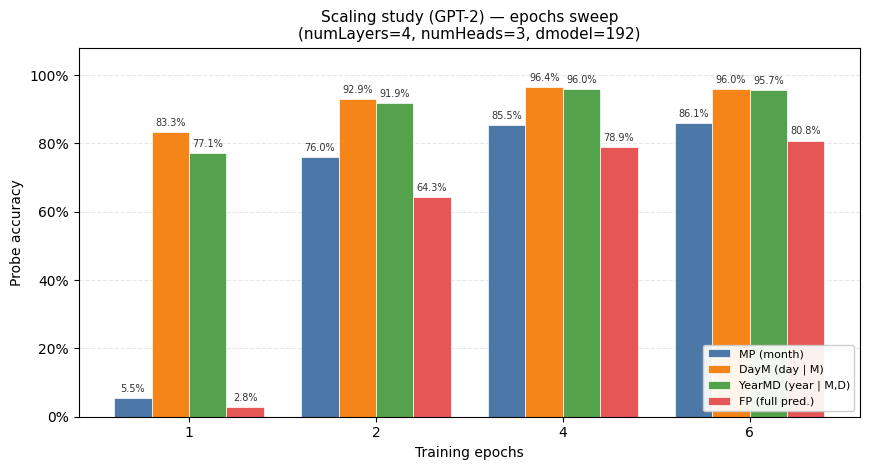

Saved → figure/scaling_epochs.png
Saved → figure/scaling_epochs_table.csv
Saved → figure/scaling_epochs_table.md


In [9]:
SCALING_CSV = "source-results/scailingStudy.csv"

scaling_df = pd.read_csv(SCALING_CSV)
_parts = scaling_df["Name"].str.split("-")
scaling_df["study"]       = _parts.str[0]
scaling_df["sweep_value"] = _parts.str[1].astype(int)

STUDY_AXES = {
    "heads":  ("Number of attention heads",   "numLayers=4, EPOCHS=1, dmodel = 64 · heads"),
    "layers": ("Number of transformer layers", "numHeads=3, dmodel=192, EPOCHS=1"),
    "epochs": ("Training epochs",             "numLayers=4, numHeads=3, dmodel=192"),
}

print(scaling_df.groupby("study")["Name"].count().rename("n_runs"))

for study, (x_label, fixed_config) in STUDY_AXES.items():
    sub = scaling_df[scaling_df["study"] == study].sort_values("sweep_value")
    if sub.empty:
        print(f"  [skip] no rows for study={study!r}")
        continue

    x_vals = sub["sweep_value"].tolist()
    x      = np.arange(len(x_vals))
    bar_w  = 0.2
    offsets = (np.arange(len(METRICS)) - (len(METRICS) - 1) / 2) * bar_w

    fig_w = max(7, 1.2 * len(x_vals) + 4)
    fig, ax = plt.subplots(figsize=(fig_w, 4.8))

    for offset, metric, label, color in zip(offsets, METRICS, LABELS, COLORS):
        ys = sub[metric].values.astype(float)
        bars = ax.bar(
            x + offset, ys, bar_w,
            label=label, color=color, edgecolor="white", linewidth=0.5,
        )
        for bar, y in zip(bars, ys):
            ax.text(
                bar.get_x() + bar.get_width() / 2, y + 0.012,
                f"{y * 100:.1f}%",
                ha="center", va="bottom", fontsize=7, color="#333",
            )

    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in x_vals])
    ax.set_xlabel(x_label)
    ax.set_ylabel("Probe accuracy")
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.set_title(f"Scaling study (GPT-2) — {study} sweep\n({fixed_config})",
                 fontsize=11)
    ax.legend(loc="lower right", fontsize=8, framealpha=0.92)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    fig.tight_layout()

    out_path = FIGURE_DIR / f"scaling_{study}.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path}")

    tbl = sub.set_index("sweep_value")[METRICS]
    tbl.columns = SHORT_LABELS
    tbl.index.name = AXIS_LABEL[study]
    tbl = (tbl.astype(float) * 100).round(1)

    csv_path = FIGURE_DIR / f"scaling_{study}_table.csv"
    md_path  = FIGURE_DIR / f"scaling_{study}_table.md"
    tbl.to_csv(csv_path)
    md_path.write_text(
        f"### Scaling study (GPT-2) — {study} sweep (probe accuracy %)\n\n"
        + df_to_markdown(tbl) + "\n"
    )
    print(f"Saved → {csv_path}")
    print(f"Saved → {md_path}")

## Grid study — Llama BD + CITY (partial)

Reads `source-results/(partialResults)_BD_CITY_grid.csv`, the joint
`(numLayers × numHeads × EPOCHS) = (4 × 4 × 4)` sweep with both probes
(`PROBES = ("sequential", "separate")`).

Each probe gets its own figure: a grid of L×H heatmaps, one row per probe
metric and one column per epoch (so you can read scaling across **L**, **H**,
**E** at a glance). Long-form `(L, H, E, metrics…)` tables are saved alongside.

Outputs (prefix `grid_`):

| File | Contents |
| --- | --- |
| `figure/grid_sequential.png` | sequential probe — `{birthday,birthcity}/{TF,FP}` + `FP_FULL` across L×H per epoch |
| `figure/grid_separate.png`   | separate probe — `{birthday,birthcity}/{TF,FP}` across L×H per epoch |
| `figure/grid_{sequential,separate}_table.{csv,md}` | one row per `(L, H, E)`, columns = probe metrics (%) |

Still-running runs (`State != "finished"`) are dropped.

In [ ]:
GRID_CSV = "source-results/(partialResults)_BD_CITY_grid.csv"

grid_df = pd.read_csv(GRID_CSV, low_memory=False)

# Drop still-running rows — their probe columns are empty.
grid_df = grid_df[grid_df["State"] == "finished"].copy()

# Run names look like "grid-L4-H4-E8-20260518-155004". Parse L / H / E.
_pat = grid_df["Name"].str.extract(r"grid-L(?P<L>\d+)-H(?P<H>\d+)-E(?P<E>\d+)")
grid_df["numLayers"] = _pat["L"].astype(int)
grid_df["numHeads"]  = _pat["H"].astype(int)
grid_df["EPOCHS"]    = _pat["E"].astype(int)

# Sequential probe outputs birthday first, then birthcity (run name "Bd-Bc"),
# so list TF/FP in that order; FP_FULL is the both-fields-correct strict score.
SEQ_METRICS = [
    "sequentialProbe/birthday/TF",
    "sequentialProbe/birthcity/TF",
    "sequentialProbe/birthday/FP",
    "sequentialProbe/birthcity/FP",
    "sequentialProbe/FP_FULL",
]
SEQ_SHORT = ["birthday/TF", "birthcity/TF", "birthday/FP", "birthcity/FP", "FP_FULL"]

SEP_METRICS = [
    "separateProbe/birthday/TF",
    "separateProbe/birthcity/TF",
    "separateProbe/birthday/FP",
    "separateProbe/birthcity/FP",
]
SEP_SHORT = ["birthday/TF", "birthcity/TF", "birthday/FP", "birthcity/FP"]

ALL_METRICS = SEQ_METRICS + SEP_METRICS
for c in ALL_METRICS:
    grid_df[c] = pd.to_numeric(grid_df[c], errors="coerce")
grid_df = grid_df.dropna(subset=ALL_METRICS, how="all")

L_VALS = sorted(grid_df["numLayers"].unique())
H_VALS = sorted(grid_df["numHeads"].unique())
E_VALS = sorted(grid_df["EPOCHS"].unique())

print(f"{len(grid_df)} finished grid runs")
print(f"  numLayers ∈ {L_VALS}")
print(f"  numHeads  ∈ {H_VALS}")
print(f"  EPOCHS    ∈ {E_VALS}")


def _grid_matrix(metric: str, e: int) -> np.ndarray:
    """L×H matrix for `metric` at fixed `EPOCHS=e`. Missing cells are NaN."""
    mat = np.full((len(L_VALS), len(H_VALS)), np.nan)
    for i, l in enumerate(L_VALS):
        for j, h in enumerate(H_VALS):
            row = grid_df[
                (grid_df["numLayers"] == l)
                & (grid_df["numHeads"] == h)
                & (grid_df["EPOCHS"] == e)
            ]
            if not row.empty:
                mat[i, j] = row[metric].iloc[0]
    return mat


def grid_heatmap_for_probe(metrics, short_labels, probe_name, out_basename):
    """Faceted heatmap: rows = metrics, cols = epochs; each cell is L (rows) × H (cols)."""
    n_rows, n_cols = len(metrics), len(E_VALS)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.4 * n_cols + 1.4, 2.0 * n_rows + 0.8),
        squeeze=False,
    )

    for r, (metric, short) in enumerate(zip(metrics, short_labels)):
        for c, e in enumerate(E_VALS):
            ax = axes[r][c]
            mat = _grid_matrix(metric, e)
            ax.imshow(mat, vmin=0, vmax=1, cmap="viridis", aspect="auto")
            ax.set_xticks(range(len(H_VALS)))
            ax.set_xticklabels(H_VALS, fontsize=7)
            ax.set_yticks(range(len(L_VALS)))
            ax.set_yticklabels(L_VALS, fontsize=7)
            for i in range(len(L_VALS)):
                for j in range(len(H_VALS)):
                    v = mat[i, j]
                    if np.isnan(v):
                        ax.text(j, i, "—", ha="center", va="center",
                                fontsize=7, color="#bbb")
                    else:
                        ax.text(j, i, f"{v * 100:.0f}",
                                ha="center", va="center", fontsize=7,
                                color="white" if v < 0.55 else "black")
            if r == 0:
                ax.set_title(f"E = {e}", fontsize=9)
            if c == 0:
                ax.set_ylabel(f"{short}\nnumLayers", fontsize=8)
            if r == n_rows - 1:
                ax.set_xlabel("numHeads", fontsize=8)

    fig.suptitle(
        f"Grid study — {probe_name} probe (probe accuracy %, L × H per epoch)",
        fontsize=11, y=1.0,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.985))
    out_path = FIGURE_DIR / out_basename
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path}")


def save_grid_table(metrics, short_labels, probe_name, out_basename):
    """Long-form (L, H, E, metrics…) table — one row per finished run."""
    tbl = (grid_df[["numLayers", "numHeads", "EPOCHS", *metrics]]
           .sort_values(["numLayers", "numHeads", "EPOCHS"])
           .reset_index(drop=True)
           .rename(columns=dict(zip(metrics, short_labels))))
    tbl[short_labels] = (tbl[short_labels].astype(float) * 100).round(1)

    csv_path = FIGURE_DIR / f"{out_basename}.csv"
    md_path  = FIGURE_DIR / f"{out_basename}.md"
    tbl.to_csv(csv_path, index=False)

    int_cols = {"numLayers", "numHeads", "EPOCHS"}
    header = "| " + " | ".join(tbl.columns) + " |"
    sep    = "|" + "|".join([" --- "] * len(tbl.columns)) + "|"
    rows   = []
    for _, row in tbl.iterrows():
        cells = [
            str(int(row[c])) if c in int_cols else f"{row[c]:.1f}%"
            for c in tbl.columns
        ]
        rows.append("| " + " | ".join(cells) + " |")
    md_path.write_text(
        f"### Grid study — {probe_name} probe (probe accuracy %)\n\n"
        + "\n".join([header, sep, *rows]) + "\n"
    )
    print(f"Saved → {csv_path}")
    print(f"Saved → {md_path}")
    return tbl


grid_heatmap_for_probe(SEQ_METRICS, SEQ_SHORT, "sequential", "grid_sequential.png")
grid_heatmap_for_probe(SEP_METRICS, SEP_SHORT, "separate",   "grid_separate.png")

save_grid_table(SEQ_METRICS, SEQ_SHORT, "sequential", "grid_sequential_table")
save_grid_table(SEP_METRICS, SEP_SHORT, "separate",   "grid_separate_table")

## Memorize-attempts — birthday probe (16 EPOCHS)

Reads `source-results/(partial1)_Memorize_attempts_BD.csv`, two sweeps run at
`EPOCHS = 16` to probe how much capacity is needed to memorize birthday:

- `16EP_heads-N`  — numHeads ∈ {4, 6, (8 crashed)}, numLayers fixed
- `16EP_layer-N`  — numLayers ∈ {4, 6, 8, 12}, numHeads = 3, dmodel = 192

Same MP / DayM / YearMD / FP bar-chart style, but read from
`birthdayProbe/{MP,DayM,YearMD,FP}` (the run only has the birthday field).
Outputs prefixed `memorize_bd_`:

- `figure/memorize_bd_heads.png`,  `memorize_bd_heads_table.{csv,md}`
- `figure/memorize_bd_layers.png`, `memorize_bd_layers_table.{csv,md}`

study
heads     2
layers    4
Name: n_runs, dtype: int64


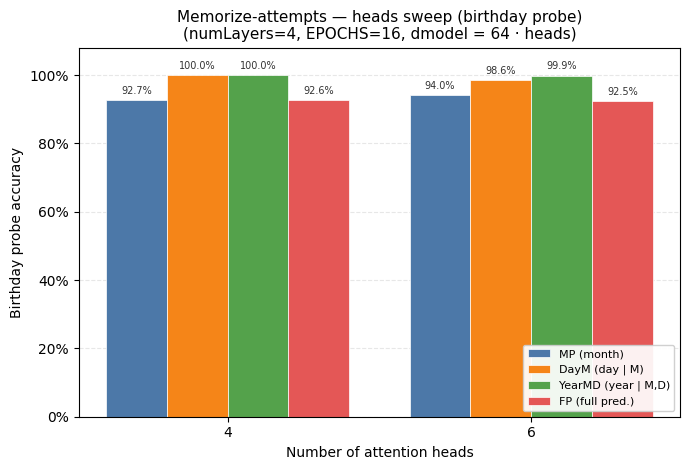

Saved → figure/memorize_bd_heads.png
Saved → figure/memorize_bd_heads_table.csv
Saved → figure/memorize_bd_heads_table.md


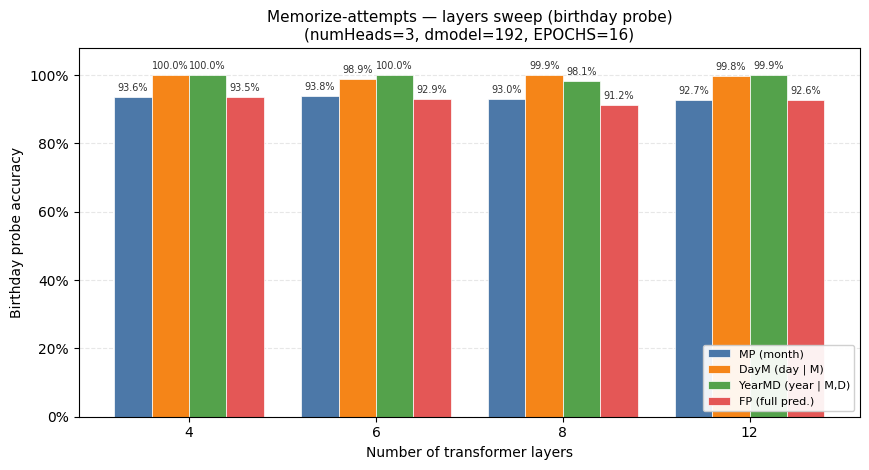

Saved → figure/memorize_bd_layers.png
Saved → figure/memorize_bd_layers_table.csv
Saved → figure/memorize_bd_layers_table.md


,MP,DayM,YearMD,FP
numLayers,,,,
4,93.6,100.0,100.0,93.5
6,93.8,98.9,100.0,92.9
8,93.0,99.9,98.1,91.2
12,92.7,99.8,99.9,92.6


In [4]:
MEMORIZE_BD_CSV = "source-results/(partial1)_Memorize_attempts_BD.csv"

# Birthday-only export uses the `birthdayProbe/*` namespace; map them onto the
# same MP / DayM / YearMD / FP positions used by `plot_study`.
BD_METRICS = [
    "birthdayProbe/MP",
    "birthdayProbe/DayM",
    "birthdayProbe/YearMD",
    "birthdayProbe/FP",
]

memorize_df = pd.read_csv(MEMORIZE_BD_CSV, low_memory=False)
memorize_df = memorize_df[memorize_df["State"] == "finished"].copy()

# Names look like "16EP_heads-6-20260518-151303" / "16EP_layer-12-...".
# Normalize "layer" → "layers" so it lines up with the rest of the notebook.
_parts = memorize_df["Name"].str.split("-")
memorize_df["study"]       = _parts.str[0].str.replace("16EP_", "", regex=False)
memorize_df["study"]       = memorize_df["study"].replace({"layer": "layers"})
memorize_df["sweep_value"] = _parts.str[1].astype(int)
for c in BD_METRICS:
    memorize_df[c] = pd.to_numeric(memorize_df[c], errors="coerce")

print(memorize_df.groupby("study")["Name"].count().rename("n_runs"))


def plot_memorize_study(study: str, x_label: str, fixed_config: str, out_name: str):
    sub = memorize_df[memorize_df["study"] == study].sort_values("sweep_value")
    if sub.empty:
        raise ValueError(
            f"No rows for study={study!r}. Found: {sorted(memorize_df['study'].unique())}"
        )

    x_vals = sub["sweep_value"].tolist()
    x      = np.arange(len(x_vals))
    bar_w  = 0.2
    offsets = (np.arange(len(BD_METRICS)) - (len(BD_METRICS) - 1) / 2) * bar_w

    fig_w = max(7, 1.2 * len(x_vals) + 4)
    fig, ax = plt.subplots(figsize=(fig_w, 4.8))

    for offset, metric, label, color in zip(offsets, BD_METRICS, LABELS, COLORS):
        ys = sub[metric].values.astype(float)
        bars = ax.bar(
            x + offset, ys, bar_w,
            label=label, color=color, edgecolor="white", linewidth=0.5,
        )
        for bar, y in zip(bars, ys):
            ax.text(
                bar.get_x() + bar.get_width() / 2, y + 0.012,
                f"{y * 100:.1f}%",
                ha="center", va="bottom", fontsize=7, color="#333",
            )

    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in x_vals])
    ax.set_xlabel(x_label)
    ax.set_ylabel("Birthday probe accuracy")
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.set_title(
        f"Memorize-attempts — {study} sweep (birthday probe)\n({fixed_config})",
        fontsize=11,
    )
    ax.legend(loc="lower right", fontsize=8, framealpha=0.92)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    fig.tight_layout()

    out_path = FIGURE_DIR / out_name
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out_path}")

    tbl = sub.set_index("sweep_value")[BD_METRICS]
    tbl.columns = SHORT_LABELS
    tbl.index.name = AXIS_LABEL[study]
    tbl = (tbl.astype(float) * 100).round(1)

    base = out_name.removesuffix(".png")
    csv_path = FIGURE_DIR / f"{base}_table.csv"
    md_path  = FIGURE_DIR / f"{base}_table.md"
    tbl.to_csv(csv_path)
    md_path.write_text(
        f"### Memorize-attempts — {study} sweep, birthday probe (accuracy %)\n\n"
        + df_to_markdown(tbl) + "\n"
    )
    print(f"Saved → {csv_path}")
    print(f"Saved → {md_path}")
    return tbl


plot_memorize_study(
    study="heads",
    x_label="Number of attention heads",
    fixed_config="numLayers=4, EPOCHS=16, dmodel = 64 · heads",
    out_name="memorize_bd_heads.png",
)
plot_memorize_study(
    study="layers",
    x_label="Number of transformer layers",
    fixed_config="numHeads=3, dmodel=192, EPOCHS=16",
    out_name="memorize_bd_layers.png",
)

## Grid study — Name + Birthday line grid

Reads `source-results/grid-study-Name-BD.csv`, a full
`numLayers ∈ {1, 2, 4, 8}` × `numHeads ∈ {1, 2, 4, 6, 8}` sweep with probe
checkpoints at `epoch ∈ {1, 2, 4, 6, 8, 12, 16}`.

Each panel is one `(L, H)` cell of the grid; lines plot the five probe metrics
(`M`, `Day_M`, `Year_MD`, `FP`, `LP`) against training epoch. `dmodel = 64 · H`
per the paper convention. Saved as `figure/grid_name_bd.png`.

source-results/grid-study-Name-BD.csv: 140 rows, 20/20 runs present


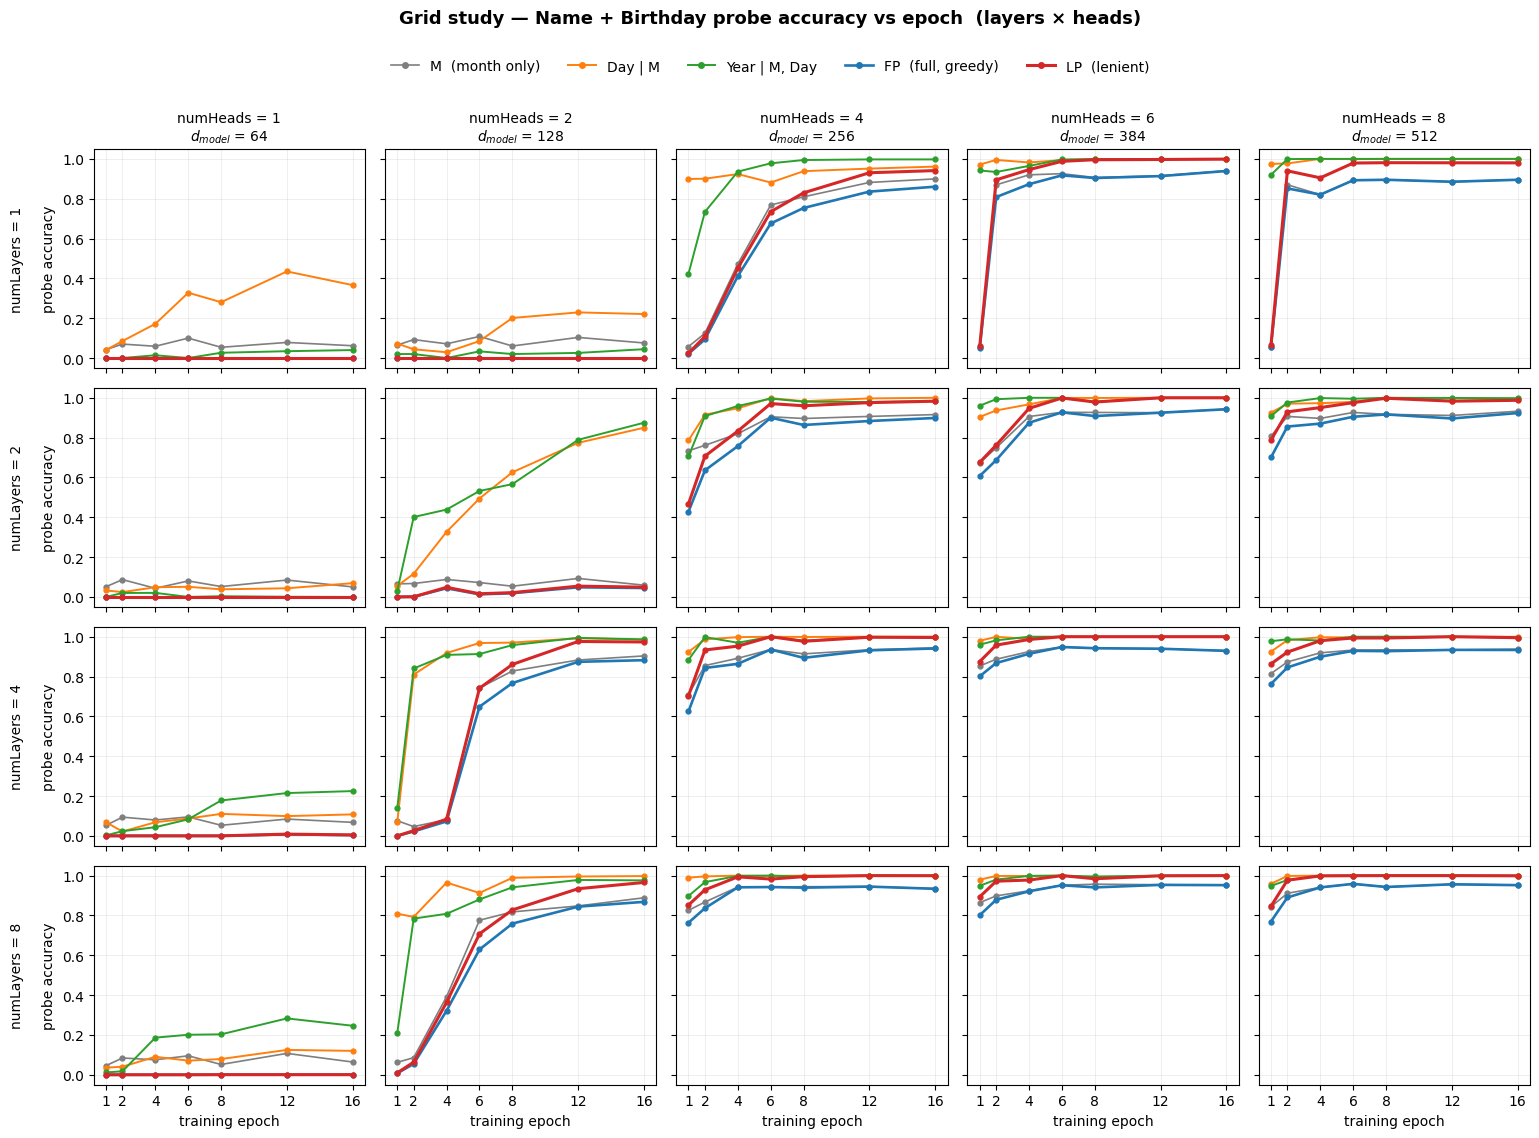

Saved → figure/grid_name_bd.png
Saved → figure/grid_name_bd_table.csv


In [5]:
from matplotlib.lines import Line2D

NAME_BD_CSV = "source-results/grid-study-Name-BD.csv"

name_bd_df = pd.read_csv(NAME_BD_CSV)

GRID_LAYERS = [1, 2, 4, 8]
GRID_HEADS  = [1, 2, 4, 6, 8]
GRID_EPOCHS = [1, 2, 4, 6, 8, 12, 16]
GRID_METRICS = [
    ("M",       "tab:gray",   1.2, "M  (month only)"),
    ("Day_M",   "tab:orange", 1.4, "Day | M"),
    ("Year_MD", "tab:green",  1.4, "Year | M, Day"),
    ("FP",      "tab:blue",   1.9, "FP  (full, greedy)"),
    ("LP",      "tab:red",    2.2, "LP  (lenient)"),
]

print(f"{NAME_BD_CSV}: {len(name_bd_df)} rows, "
      f"{name_bd_df['run_name'].nunique()}/{len(GRID_LAYERS) * len(GRID_HEADS)} runs present")
for L in GRID_LAYERS:
    for H in GRID_HEADS:
        n = len(name_bd_df[(name_bd_df.numLayers == L) & (name_bd_df.numHeads == H)])
        if n == 0:
            print(f"  L{L}-H{H}: not run yet")
        elif n < len(GRID_EPOCHS):
            print(f"  L{L}-H{H}: partial ({n}/{len(GRID_EPOCHS)} probe epochs)")

fig, axes = plt.subplots(
    len(GRID_LAYERS), len(GRID_HEADS),
    figsize=(3.1 * len(GRID_HEADS), 2.7 * len(GRID_LAYERS)),
    sharex=True, sharey=True,
)

for i, L in enumerate(GRID_LAYERS):
    for j, H in enumerate(GRID_HEADS):
        ax = axes[i][j]
        sub = (name_bd_df[(name_bd_df.numLayers == L) & (name_bd_df.numHeads == H)]
               .sort_values("epoch"))
        if len(sub):
            for col, color, lw, _ in GRID_METRICS:
                ax.plot(sub["epoch"], sub[col], "-o",
                        ms=3.5, lw=lw, color=color)
        else:
            ax.text(0.5, 0.5, "not run yet", transform=ax.transAxes,
                    ha="center", va="center", color="0.6", style="italic")
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(GRID_EPOCHS)
        ax.grid(alpha=0.3, lw=0.5)
        if i == 0:
            ax.set_title(f"numHeads = {H}\n$d_{{model}}$ = {64 * H}", fontsize=10)
        if j == 0:
            ax.set_ylabel(f"numLayers = {L}\n\nprobe accuracy", fontsize=10)
        if i == len(GRID_LAYERS) - 1:
            ax.set_xlabel("training epoch")

handles = [Line2D([], [], color=c, marker="o", ms=4, lw=lw, label=lbl)
           for _, c, lw, lbl in GRID_METRICS]
fig.legend(handles=handles, ncol=len(GRID_METRICS), loc="upper center",
           bbox_to_anchor=(0.5, 1.015), frameon=False, fontsize=10)
fig.suptitle("Grid study — Name + Birthday probe accuracy vs epoch  (layers × heads)",
             y=1.05, fontsize=13, weight="bold")
fig.tight_layout()

out_path = FIGURE_DIR / "grid_name_bd.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

# Long-form per-(L, H, epoch) table for reference.
name_bd_tbl = (name_bd_df[["numLayers", "numHeads", "epoch",
                           "M", "Day_M", "Year_MD", "FP", "LP"]]
               .sort_values(["numLayers", "numHeads", "epoch"])
               .reset_index(drop=True))
for c in ("M", "Day_M", "Year_MD", "FP", "LP"):
    name_bd_tbl[c] = (name_bd_tbl[c].astype(float) * 100).round(1)

csv_path = FIGURE_DIR / "grid_name_bd_table.csv"
name_bd_tbl.to_csv(csv_path, index=False)
print(f"Saved → {csv_path}")